## Eploratory Data Analysis

## 1. Importing Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("seaborn-v0_8")

## 2. Loading The DataSet

In [4]:
DATA_PATH='../data/raw/car details v4.csv'

cars=pd.read_csv(DATA_PATH)
df=cars.copy()

## 3. Dataset Overview

In [5]:
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [7]:
df.describe(include='all')

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
count,8128,8128.000000,8.128000e+03,8.128000e+03,8128,8128,8128,8128,7907,7907,7913,7906,7907.000000
unique,2058,NaN,NaN,NaN,4,3,2,5,393,121,322,441,NaN
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,NaN
freq,129,NaN,NaN,NaN,4402,6766,7078,5289,225,1017,377,530,NaN
mean,NaN,2013.804011,6.382718e+05,6.981951e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.416719
std,NaN,4.044249,8.062534e+05,5.655055e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959588
min,NaN,1983.000000,2.999900e+04,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,2011.000000,2.549990e+05,3.500000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,2015.000000,4.500000e+05,6.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,2017.000000,6.750000e+05,9.800000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000


*The dataset contains both numerical and categorical features.
Several vehicle specifications such as mileage, engine, and power
are stored as object types because they contain measurement units.
These columns will require preprocessing in later phases.*

## 4. Feature Documentation

| Feature | Description | Type | Comments |
|---|---|---|---|
| name | Car model | Categorical | High cardinality |
| year | Manufacturing year | Numeric (Discrete) | Can derive age |
| selling_price | Target variable | Continuous | Right skewed |
| km_driven | Kilometers driven | Numeric | Potential outliers |
| fuel | Fuel type | Categorical | |
| seller_type | Seller category | Categorical | |
| transmission | Manual/Automatic | Binary categorical | |
| owner | Previous owners | Ordinal | |
| mileage | Fuel efficiency | Object (Needs cleaning) | Contains units |
| engine | Engine capacity | Object (Needs cleaning) | Contains "CC" |
| max_power | Maximum power | Object (Needs cleaning) | Contains "bhp" |
| torque | Engine torque | Object (Needs significant parsing) | Complex format |
| seats | Number of seats | Numeric (Discrete) | Missing values|

## 5. Brand Analysis

In [8]:
df['brand']=df['name'].str.split().str[0]

df['brand'].value_counts().head(20)

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Name: count, dtype: int64

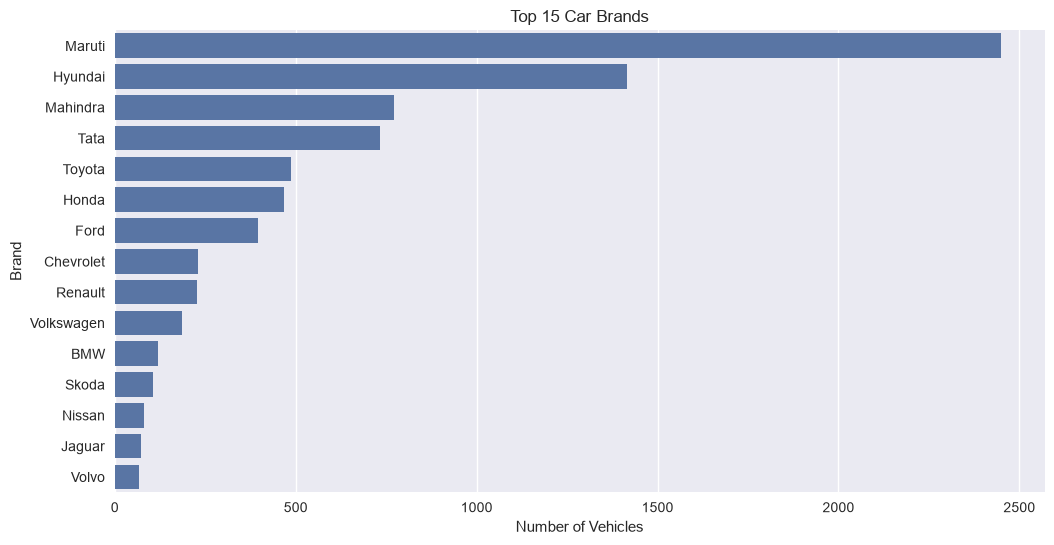

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=df["brand"].value_counts().head(15).values,
    y=df["brand"].value_counts().head(15).index
)

plt.title("Top 15 Car Brands")
plt.xlabel("Number of Vehicles")
plt.ylabel("Brand")

plt.show()

*The dataset is concentrated around a few manufacturers.*
**The 5 Most Popular brands are:**`Maruti: 2448 , Hyundai: 1415 , Mahindra: 772 , Tata: 734 , Toyota: 488 `



## 6. Vehicle Age Analysis

In [10]:
df['year'].describe()

count    8128.000000
mean     2013.804011
std         4.044249
min      1983.000000
25%      2011.000000
50%      2015.000000
75%      2017.000000
max      2020.000000
Name: year, dtype: float64

In [40]:
df['year'].value_counts()

year
2017    1018
2016     859
2018     807
2015     776
2013     670
2012     651
2014     621
2011     592
2019     583
2010     394
2009     246
2008     214
2007     183
2006     124
2005      97
2020      74
2004      62
2003      49
2002      27
2000      22
1999      18
1997      11
2001      10
1998      10
1996       3
1994       3
1995       2
1983       1
1991       1
Name: count, dtype: int64

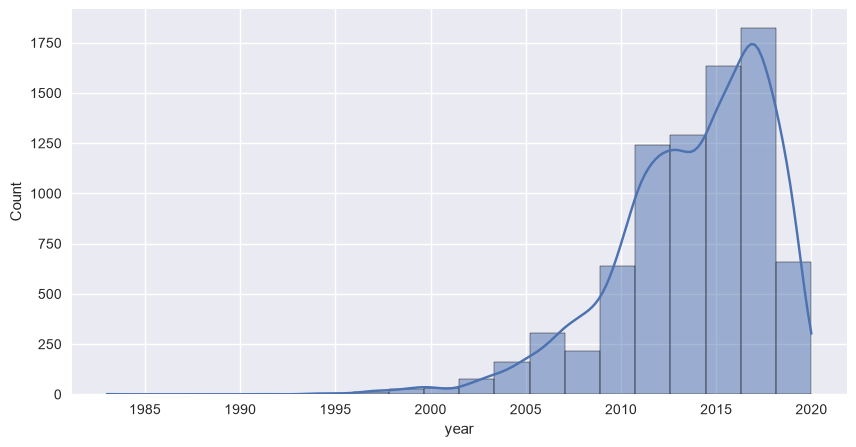

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['year'],
    bins=20,
    kde=True
)
plt.show()

*Most vehicles belong to recent manufacturing years.
Older vehicles are less frequent and may represent a smaller
segment of the market.*

## 7. Km_Driven Analysis

In [12]:
df['km_driven'].skew()

np.float64(11.170909783549087)

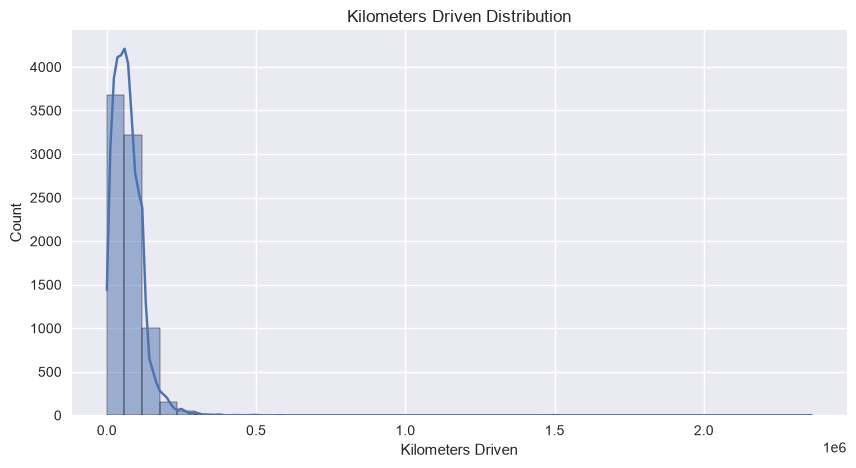

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['km_driven'],kde=True ,bins=40)

plt.title("Kilometers Driven Distribution")
plt.xlabel("Kilometers Driven")

plt.show()

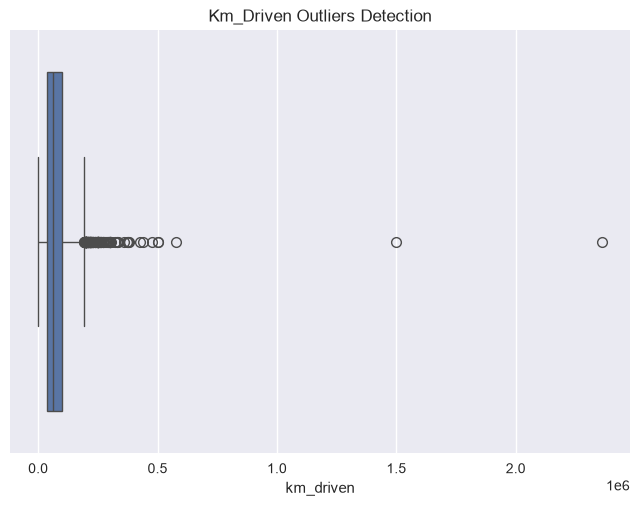

In [14]:
sns.boxplot(x=df['km_driven'])

plt.title("Km_Driven Outliers Detection")
plt.show()

*The km_driven feature shows a right-skewed distribution.
A small number of vehicles have extremely high mileage,
which may require investigation during cleaning.Boxplot also revealed some extreme outliers*

## 8. Fuel Type Analysis

In [15]:
df['fuel'].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

C:\Users\Saad\AppData\Local\Temp\ipykernel_14328\1911272390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


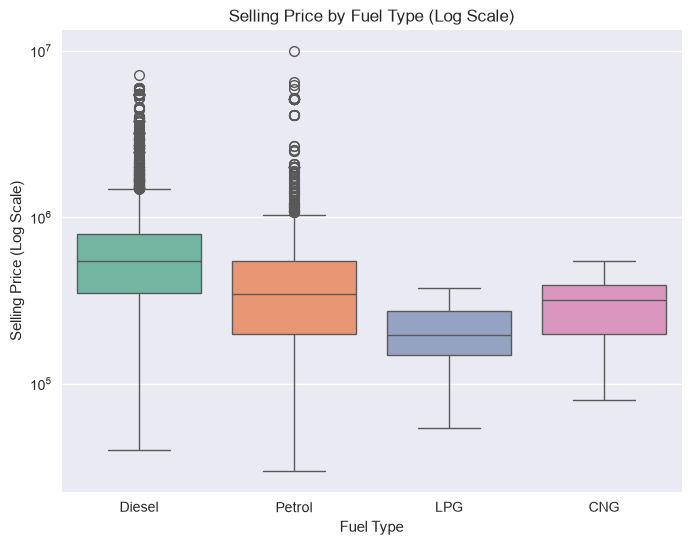

In [45]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price",
    palette="Set2"
)

plt.yscale("log")

plt.title("Selling Price by Fuel Type (Log Scale)")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Log Scale)")

plt.show()

- *The dataset is dominated by traditional fuel categories (`Diesel and Petrol`).*
- *There are no electric vehicles*
- *Rare fuel categories may require careful handling during modeling*

## 9. Transmission Analysis

In [17]:
df['transmission'].value_counts()

transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

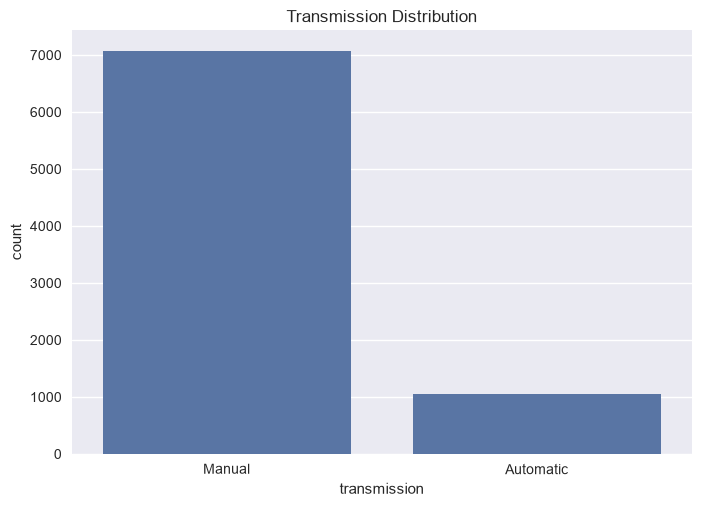

In [18]:
sns.countplot(
    data=df,
    x="transmission"
)

plt.title("Transmission Distribution")

plt.show()

C:\Users\Saad\AppData\Local\Temp\ipykernel_14328\3242432386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


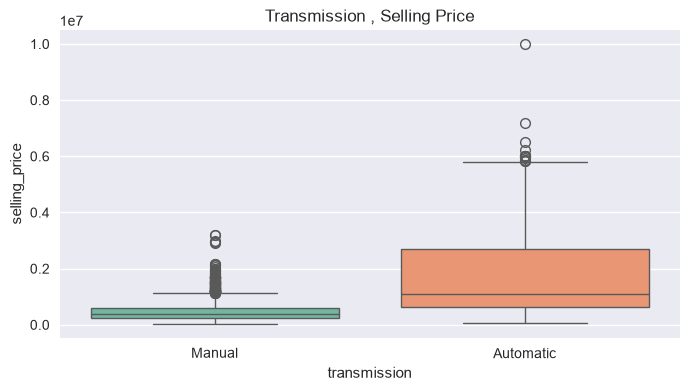

In [47]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df,
    x='transmission',
    y='selling_price',
    palette='Set2'
    
)

plt.title("Transmission , Selling Price")
plt.show()

*Manual transmission vehicles represent the majority of observations.
Automatic vehicles may be underrepresented*

## 10. Seller Analysis

In [19]:
df['seller_type'].value_counts()

seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

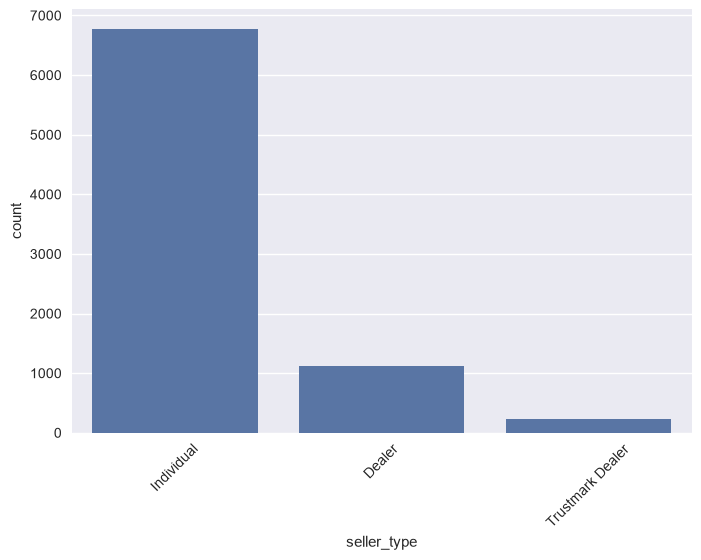

In [20]:
sns.countplot(
    data=df,
    x="seller_type"
)

plt.xticks(rotation=45)
plt.show()

C:\Users\Saad\AppData\Local\Temp\ipykernel_14328\1991921989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


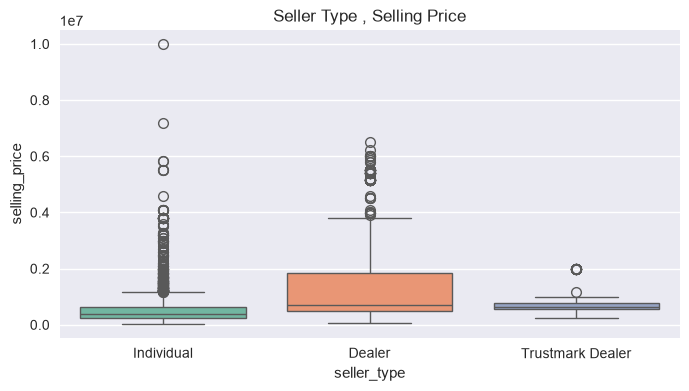

In [49]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df,
    x='seller_type',
    y='selling_price',
    palette='Set2'
    
)

plt.title("Seller Type , Selling Price")
plt.show()

**Seller Type**
- Individual          `6766`
- Dealer              `1126`
- Trustmark Dealer     `236`

## 11. Owner Analysis

In [21]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

Text(0.5, 1.0, 'Owner Count Plot')

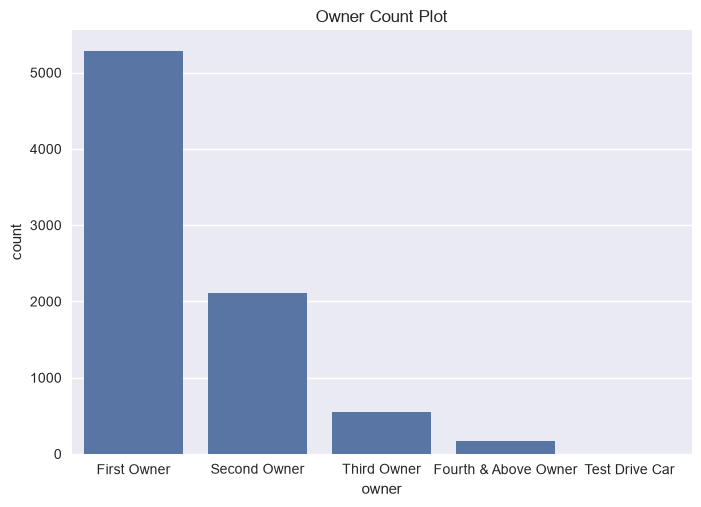

In [22]:
sns.countplot(x=df['owner'])
plt.title('Owner Count Plot')

C:\Users\Saad\AppData\Local\Temp\ipykernel_14328\2841426580.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0.5, 1.0, 'Owner, Selling Price')

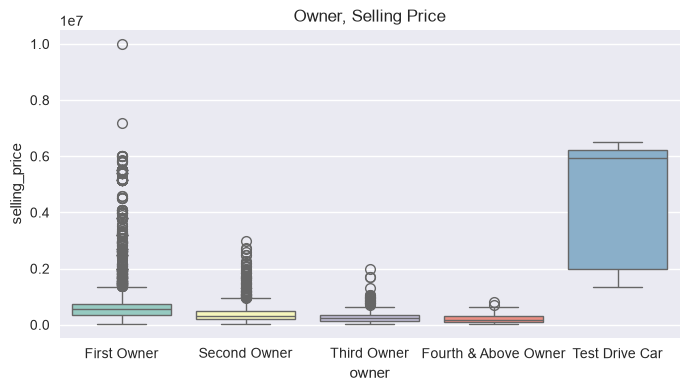

In [59]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df,
    x='owner',
    y='selling_price',
    palette='Set3'
    
)

plt.title("Owner, Selling Price")

## 12. Relationship with target

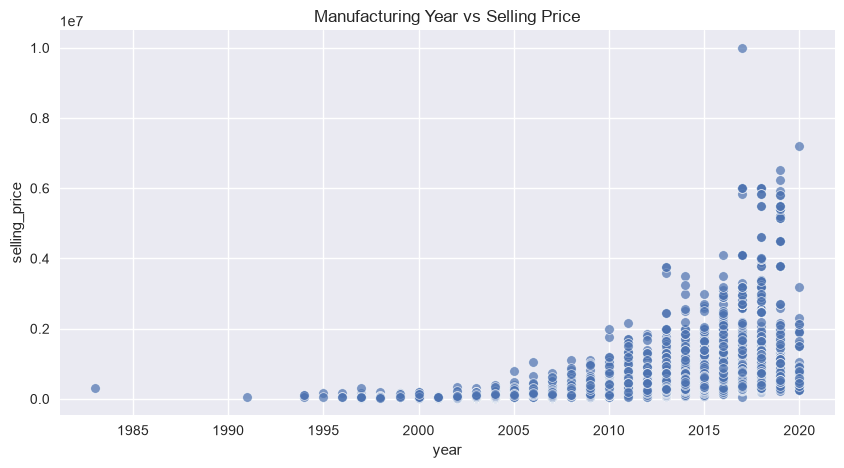

In [23]:
# year vs price
plt.figure(figsize=(10,5))
sns.scatterplot( x=df['year'],y=df['selling_price'],alpha=0.7)
plt.title(
    "Manufacturing Year vs Selling Price"
)

plt.show()

*This relation through scatter plot shows that the newer vehicles have more selling price compared to the older vehicles*

**The relationship is not perfectly linear beacuse other features also effect the `selling price`**

Text(0.5, 1.0, 'Km_Driven Vs Salling Price')

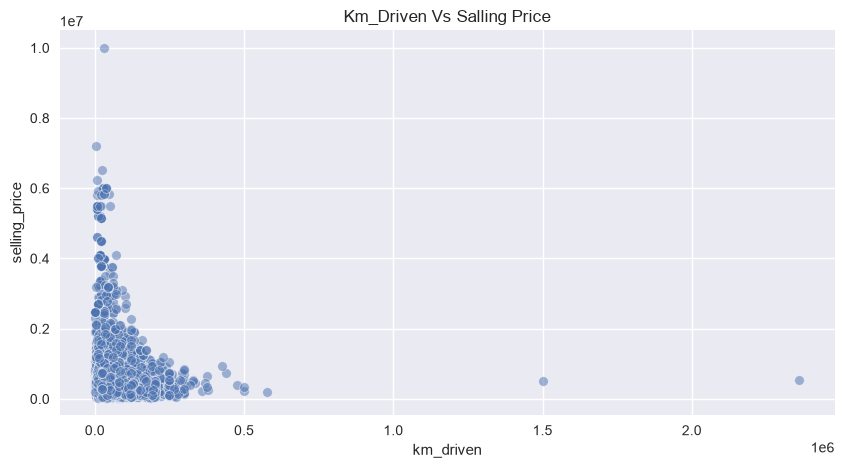

In [24]:
# KM_driven vs selling price 
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x='km_driven',y='selling_price',alpha=0.5)

plt.title("Km_Driven Vs Salling Price")

**Higher mileage generally reduces vehicle price.**

In [25]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats', 'brand'],
      dtype='str')

## 10. Correlation Analysis

In [ ]:

corr=df.corr(numeric_only=True)
display(corr)

,year,selling_price,km_driven,seats
year,1.000000,0.414092,-0.418006,-0.009144
selling_price,0.414092,1.000000,-0.225534,0.041358
km_driven,-0.418006,-0.225534,1.000000,0.227336
seats,-0.009144,0.041358,0.227336,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

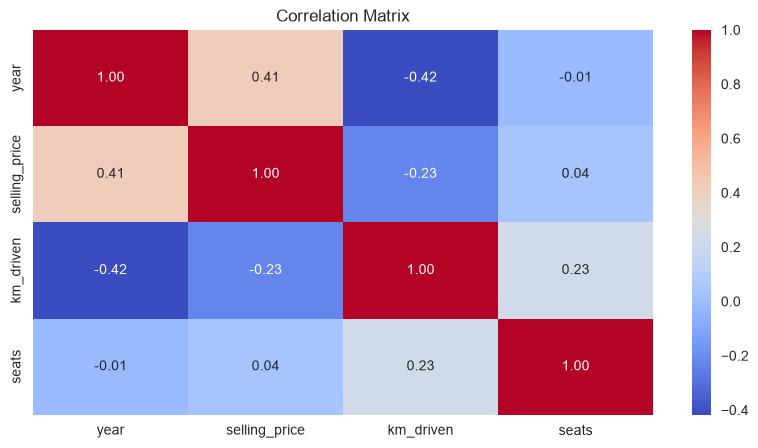

In [39]:
plt.figure(figsize=(10,5))
sns.heatmap(
    corr , 
    annot=True, 
    cmap='coolwarm',
    fmt='.2f')

plt.title('Correlation Matrix')

*Manufacturing year exhibits the strongest positive correlation with selling_price, while km_driven shows a negative correlation. The remaining numeric features demonstrate relatively weak linear relationships with the target, indicating that additional engineered features or nonlinear modeling techniques may improve predictive performance*

## Final Summary

The exploratory analysis indicates that vehicle age and mileage are strongly associated with selling price. The dataset is dominated by manual transmission, petrol, and diesel vehicles, while electric and alternative fuel vehicles are relatively rare. Several features (mileage, engine, max_power, and torque) require parsing before they can be used for modeling. High-cardinality categorical features, such as name, may benefit from transformation into broader categories like manufacturer.